In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
import copy
warnings.filterwarnings('ignore')
%matplotlib inline

In [9]:
df = pd.read_csv("delhi_aqi_weather_daily.csv")

df.head()

,City,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI,AQI_Bucket,Temperature,Humidity,WindSpeed,WindDirection,Rain,month,day_of_week,day_of_year
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,...,204.5,Severe,16.145833,68.083333,1.660000,95.708333,0.0,1,3,1
1,Delhi,2015-01-02,344.2,173.2,179.8,128.4,156.1,15.6,6.28,7.5,...,238.5,Satisfactory,15.037500,84.166667,1.600417,88.916667,3.4,1,4,2
2,Delhi,2015-01-03,473.9,20.1,12.7,102.7,244.7,42.5,0.04,29.8,...,77.6,Satisfactory,15.441667,84.000000,1.421667,276.791667,0.5,1,5,3
3,Delhi,2015-01-04,32.4,414.8,198.1,25.6,218.2,13.2,2.47,50.4,...,85.4,Satisfactory,14.162500,79.250000,2.807500,313.291667,0.0,1,6,4
4,Delhi,2015-01-05,312.8,155.8,143.1,106.8,6.1,4.9,4.04,2.0,...,396.8,Poor,13.995833,74.208333,5.365417,299.041667,0.0,1,0,5


In [10]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["month"].apply(get_season)

In [11]:
df.head()

,City,Date,PM25,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI_Bucket,Temperature,Humidity,WindSpeed,WindDirection,Rain,month,day_of_week,day_of_year,Season
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,...,Severe,16.145833,68.083333,1.660000,95.708333,0.0,1,3,1,Winter
1,Delhi,2015-01-02,344.2,173.2,179.8,128.4,156.1,15.6,6.28,7.5,...,Satisfactory,15.037500,84.166667,1.600417,88.916667,3.4,1,4,2,Winter
2,Delhi,2015-01-03,473.9,20.1,12.7,102.7,244.7,42.5,0.04,29.8,...,Satisfactory,15.441667,84.000000,1.421667,276.791667,0.5,1,5,3,Winter
3,Delhi,2015-01-04,32.4,414.8,198.1,25.6,218.2,13.2,2.47,50.4,...,Satisfactory,14.162500,79.250000,2.807500,313.291667,0.0,1,6,4,Winter
4,Delhi,2015-01-05,312.8,155.8,143.1,106.8,6.1,4.9,4.04,2.0,...,Poor,13.995833,74.208333,5.365417,299.041667,0.0,1,0,5,Winter


In [12]:
df = pd.get_dummies(
    df,
    columns=["Season"],
    drop_first=True
)

### Creating lag features

In [41]:
df["PM25_lag1"] = df["PM25"].shift(1)     ## yesterday's PM2.5 
df["PM25_lag3"] = df["PM25"].shift(3)     ## PM2.5 3 days ago
df["PM25_lag7"] = df["PM25"].shift(7)     ## PM2.5 1 week ago

In [42]:
df["PM10_lag1"] = df["PM10"].shift(1)
df["PM10_lag3"] = df["PM10"].shift(3)
df["PM10_lag7"] = df["PM10"].shift(7)

#### Creating rolling features

In [45]:
df["PM25_rolling_7"] = (
    df["PM25"]
    .rolling(window=7)
    .mean()
)

In [46]:
df["PM10_rolling_7"] = (
    df["PM10"]
    .rolling(window=7)
    .mean()
)

In [ ]:
df["AQI_rolling_7"] = (
    df["AQI"]
    .rolling(window=7)
    .mean()
)

In [47]:
df[["Date","PM25","Target_PM25"]].tail()

,Date,PM25,Target_PM25
3627,2024-12-06,277.0,257.3
3628,2024-12-07,257.3,374.7
3629,2024-12-08,374.7,332.0
3630,2024-12-09,332.0,121.7
3631,2024-12-10,121.7,15.6


In [49]:
df.isnull().sum()

City              0
Date              0
PM25              0
PM10              0
NO                0
NO2               0
NOx               0
NH3               0
CO                0
SO2               0
O3                0
Benzene           0
Toluene           0
Xylene            0
AQI               0
AQI_Bucket        0
Temperature       0
Humidity          0
WindSpeed         0
WindDirection     0
Rain              0
month             0
day_of_week       0
day_of_year       0
Season_Monsoon    0
Season_Summer     0
Season_Winter     0
Target_PM25       0
Target_PM10       0
PM25_lag1         1
PM25_lag3         3
PM25_lag7         7
PM10_lag1         1
PM10_lag3         3
PM10_lag7         7
PM10_rolling_7    6
PM25_rolling_7    6
AQI_rolling_7     0
dtype: int64

In [51]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

### Create targets, tomorrow's PM2.5 and PM10

In [53]:
df["Target_PM25"] = df["PM25"].shift(-1)
df["Target_PM10"] = df["PM10"].shift(-1)

In [64]:
df.dropna(inplace=True)

##### Selecting features

In [55]:
drop_cols = [
    "Date",
    "City",
    "PM25",
    "PM10",
    "AQI",
    "AQI_Bucket",
    "Target_PM25",
    "Target_PM10"
]

X = df.drop(columns=drop_cols)

### Predicting PM2.5 and PM10 first then AQI accordingly

In [65]:
y_pm25 = df["Target_PM25"]
y_pm10 = df["Target_PM10"]

In [66]:
print(X.columns.tolist())

['NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Temperature', 'Humidity', 'WindSpeed', 'WindDirection', 'Rain', 'month', 'day_of_week', 'day_of_year', 'Season_Monsoon', 'Season_Summer', 'Season_Winter', 'PM25_lag1', 'PM25_lag3', 'PM25_lag7', 'PM10_lag1', 'PM10_lag3', 'PM10_lag7', 'PM10_rolling_7', 'PM25_rolling_7', 'AQI_rolling_7']


In [58]:
print(X.columns)

Index(['NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene',
       'Xylene', 'Temperature', 'Humidity', 'WindSpeed', 'WindDirection',
       'Rain', 'month', 'day_of_week', 'day_of_year', 'Season_Monsoon',
       'Season_Summer', 'Season_Winter', 'PM25_lag1', 'PM25_lag3', 'PM25_lag7',
       'PM10_lag1', 'PM10_lag3', 'PM10_lag7', 'PM10_rolling_7',
       'PM25_rolling_7', 'AQI_rolling_7'],
      dtype='str')


In [67]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_pm25_train = y_pm25.iloc[:split]
y_pm25_test = y_pm25.iloc[split:]

y_pm10_train = y_pm10.iloc[:split]
y_pm10_test = y_pm10.iloc[split:]

In [68]:
print("Training data:")
print(df.iloc[0]["Date"], "to", df.iloc[split-1]["Date"])

print()

print("Testing data:")
print(df.iloc[split]["Date"], "to", df.iloc[-1]["Date"])

Training data:
2015-01-15 to 2022-12-16

Testing data:
2022-12-17 to 2024-12-09


### Train PM2.5 Model

In [35]:
from xgboost import XGBRegressor

In [69]:
pm25_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

In [70]:
pm25_model.fit(X_train, y_pm25_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Evaluate PM2.5 model

In [71]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pm25_pred = pm25_model.predict(X_test)

mae = mean_absolute_error(y_pm25_test, pm25_pred)
rmse = mean_squared_error(y_pm25_test, pm25_pred) ** 0.5
r2 = r2_score(y_pm25_test, pm25_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

ValueError: Found input variables with inconsistent numbers of samples: [724, 725]

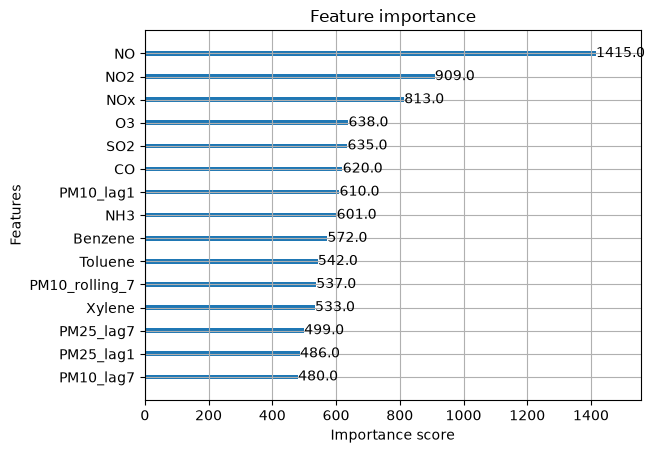

In [38]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(pm25_model, max_num_features=15)
plt.show()

In [39]:
print(df[[
    "Date",
    "PM25",
    "PM25_lag1",
    "PM25_lag3",
    "PM25_lag7",
    "Target_PM25"
]].head(10))

          Date   PM25  PM25_lag1  PM25_lag3  PM25_lag7  Target_PM25
7   2015-01-08  315.2      282.3      312.8      153.3        226.8
8   2015-01-09  226.8      315.2      390.7      344.2        316.8
9   2015-01-10  316.8      226.8      282.3      473.9        439.9
10  2015-01-11  439.9      316.8      315.2       32.4         59.0
11  2015-01-12   59.0      439.9      226.8      312.8         15.9
12  2015-01-13   15.9       59.0      316.8      390.7         33.1
13  2015-01-14   33.1       15.9      439.9      282.3         67.7
14  2015-01-15   67.7       33.1       59.0      315.2        283.3
15  2015-01-16  283.3       67.7       15.9      226.8        378.5
16  2015-01-17  378.5      283.3       33.1      316.8        486.5


In [40]:
print(df.shape)

(3625, 38)
